# **Q1: Show how seat distribution changed across Tamil Nadu’s six regions between 2021 and 2026.**

### **1) Data Audit**

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [60]:
df2021 = pd.read_csv('tn_2021_results.csv')
df2026 = pd.read_csv('tn_2026_results.csv')
df_master = pd.read_csv('constituency_master.csv')

In [61]:
df2021.head()

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipundi,1,GOVINDARAJAN T.J,DMK,126452,78.08,GEN,Chennai Metro
1,Gummidipundi,1,PRAKASH M,PMK,75514,78.08,GEN,Chennai Metro
2,Gummidipundi,1,USHA,NTK,11701,78.08,GEN,Chennai Metro
3,Gummidipundi,1,DILLIY K.M,DMDK,2576,78.08,GEN,Chennai Metro
4,Gummidipundi,1,None Of The Above,NOTA,1783,78.08,GEN,Chennai Metro


In [62]:
df2026.head()

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipoondi,1,S.VIJAYAKUMAR,TVK,94320,NaN,GEN,Chennai Metro
1,Gummidipoondi,1,SUDHAKAR.V,AIADMK,66375,NaN,GEN,Chennai Metro
2,Gummidipoondi,1,T.J.GOVINDARAJAN,DMK,62492,NaN,GEN,Chennai Metro
3,Gummidipoondi,1,"R.SRIDAR. B.L.,",NTK,4756,NaN,GEN,Chennai Metro
4,Gummidipoondi,1,NOTA,NOTA,937,NaN,GEN,Chennai Metro


In [63]:
df_master.head()

,ac_number,constituency,district,region,reserved
0,1,Gummidipundi,Tiruvallur,Chennai Metro,GEN
1,2,Ponneri,Tiruvallur,Chennai Metro,SC
2,3,Tiruttani,Tiruvallur,Chennai Metro,GEN
3,4,Thiruvallur,Tiruvallur,Chennai Metro,GEN
4,5,Poonamallee,Tiruvallur,Chennai Metro,SC


In [64]:
# Checking the shape
print(df2021.shape)
print(df2026.shape)
print(df_master.shape)

(4232, 8)
(4257, 8)
(234, 5)


In [65]:
# column overview
df2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4232 entries, 0 to 4231
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   constituency  4232 non-null   object 
 1   ac_number     4232 non-null   int64  
 2   candidate     4232 non-null   object 
 3   party         4232 non-null   object 
 4   votes         4232 non-null   int64  
 5   turnout       4232 non-null   float64
 6   reserved      4232 non-null   object 
 7   region        4232 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 264.6+ KB


In [66]:
df2026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   constituency  4257 non-null   object 
 1   ac_number     4257 non-null   int64  
 2   candidate     4257 non-null   object 
 3   party         4257 non-null   object 
 4   votes         4257 non-null   int64  
 5   turnout       0 non-null      float64
 6   reserved      4257 non-null   object 
 7   region        4257 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 266.2+ KB


In [67]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ac_number     234 non-null    int64 
 1   constituency  234 non-null    object
 2   district      234 non-null    object
 3   region        234 non-null    object
 4   reserved      234 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.3+ KB


In [68]:
# checking for null values
print(f'Null values in df2021: {df2021.isnull().sum().sum()}')
print(f'Null values in df2026: {df2026.isnull().sum().sum()}')
print(f'Null values in df_master: {df_master.isnull().sum().sum()}')

Null values in df2021: 0
Null values in df2026: 4257
Null values in df_master: 0


The **turnout** column in `tn_2026_results.csv` contains fully missing values. This aligns with the challenge brief, which states that 2026 turnout data was intentionally omitted. Since turnout is not required for the regional seat-distribution analysis in Question 1, the column was excluded from this phase of analysis.

### **2) Data Prepration**

In [69]:
# Create a mapping from ac_number to constituency name and region from df_master
constituency_map = df_master.set_index('ac_number')['constituency'].to_dict()
region_map = df_master.set_index('ac_number')['region'].to_dict()

# Apply the mapping to df2021 and df2026 to standardize constituency and region names
df2021['constituency'] = df2021['ac_number'].map(constituency_map)
df2021['region'] = df2021['ac_number'].map(region_map)
df2026['constituency'] = df2026['ac_number'].map(constituency_map)
df2026['region'] = df2026['ac_number'].map(region_map)

# Find winners for 2021, including their party
df2021_winners = df2021.loc[df2021.groupby(['ac_number', 'constituency'])['votes'].idxmax()]
df2021_winners = df2021_winners[['ac_number', 'candidate', 'party']].rename(columns={'candidate': 'winner_2021', 'party': 'party_2021'})

# Find winners for 2026, including their party
df2026_winners = df2026.loc[df2026.groupby(['ac_number', 'constituency'])['votes'].idxmax()]
df2026_winners = df2026_winners[['ac_number', 'candidate', 'party']].rename(columns={'candidate': 'winner_2026', 'party': 'party_2026'})

# Merge the winner dataframes, using df_master as the base for constituency and region info
seat_distribution = pd.merge(df_master[['ac_number', 'constituency', 'region']], df2021_winners, on='ac_number', how='left')
seat_distribution = pd.merge(seat_distribution, df2026_winners, on='ac_number', how='left')


In [70]:
seat_distribution.head()

,ac_number,constituency,region,winner_2021,party_2021,winner_2026,party_2026
0,1,Gummidipundi,Chennai Metro,GOVINDARAJAN T.J,DMK,S.VIJAYAKUMAR,TVK
1,2,Ponneri,Chennai Metro,DURAI. CHANDRASEKAR,INC,DR.RAVI.M.S,TVK
2,3,Tiruttani,Chennai Metro,S.Chandran,DMK,G.HARI,AIADMK
3,4,Thiruvallur,Chennai Metro,"RAAJENDRAN, V.G.",DMK,DR. T. ARUNKUMAR,TVK
4,5,Poonamallee,Chennai Metro,Krishnaswamy A,DMK,PRAKASAM.R,TVK


In [71]:
# Create a long format DataFrame for 2021 seats
df_2021_long = seat_distribution[['region', 'party_2021']].copy()
df_2021_long = df_2021_long.rename(columns={'party_2021': 'party'})
df_2021_long['year'] = 2021
df_2021_long['seats'] = 1

# Create a long format DataFrame for 2026 seats
df_2026_long = seat_distribution[['region', 'party_2026']].copy()
df_2026_long = df_2026_long.rename(columns={'party_2026': 'party'})
df_2026_long['year'] = 2026
df_2026_long['seats'] = 1

# Concatenate the two DataFrames to create a merged view suitable for grouping by year
df_merged = pd.concat([df_2021_long, df_2026_long])

# Aggregate seats by region, party, and year
party_regional_seats = df_merged.groupby(['region', 'party', 'year'])['seats'].sum().unstack(level='year', fill_value=0).reset_index()

# Rename columns for clarity
party_regional_seats.columns.name = None
party_regional_seats = party_regional_seats.rename(columns={2021: 'seats_2021', 2026: 'seats_2026'})

# Calculate seat change
party_regional_seats['seat_change'] = party_regional_seats['seats_2026'] - party_regional_seats['seats_2021']

# Display the resulting table
display(party_regional_seats)

,region,party,seats_2021,seats_2026,seat_change
0,Central,AIADMK,15,15,0
1,Central,DMDK,0,1,1
2,Central,DMK,21,8,-13
3,Central,INC,1,0,-1
4,Central,PMK,3,3,0
5,Central,TVK,0,12,12
6,Central,VCK,1,2,1
7,Chennai Metro,AIADMK,0,1,1
8,Chennai Metro,DMK,29,2,-27
9,Chennai Metro,INC,3,0,-3


In [72]:
# Calculate total seats per region for 2021 and 2026
total_regional_seats_2021 = seat_distribution.groupby('region')['winner_2021'].count().reset_index(name='total_seats_2021')
total_regional_seats_2026 = seat_distribution.groupby('region')['winner_2026'].count().reset_index(name='total_seats_2026')

# Calculate seats won by each party per region for 2021 and 2026
party_seats_2021 = seat_distribution.groupby(['region', 'party_2021']).size().reset_index(name='party_seats_2021')
party_seats_2026 = seat_distribution.groupby(['region', 'party_2026']).size().reset_index(name='party_seats_2026')

# Merge party seats with total regional seats for 2021
party_seats_2021 = pd.merge(party_seats_2021, total_regional_seats_2021, on='region', how='left')
party_seats_2021['seat_share_2021'] = (party_seats_2021['party_seats_2021'] / party_seats_2021['total_seats_2021'] * 100).round(2)
party_seats_2021 = party_seats_2021.rename(columns={'party_2021': 'party'})

# Merge party seats with total regional seats for 2026
party_seats_2026 = pd.merge(party_seats_2026, total_regional_seats_2026, on='region', how='left')
party_seats_2026['seat_share_2026'] = (party_seats_2026['party_seats_2026'] / party_seats_2026['total_seats_2026'] * 100).round(2)
party_seats_2026 = party_seats_2026.rename(columns={'party_2026': 'party'})

# Merge the 2021 and 2026 seat shares
regional_seat_share = pd.merge(party_seats_2021[['region', 'party', 'seat_share_2021']],
                               party_seats_2026[['region', 'party', 'seat_share_2026']],
                               on=['region', 'party'], how='outer')

# Fill NaN values with 0 for parties that didn't win seats in a particular year/region
regional_seat_share = regional_seat_share.fillna(0)

display(regional_seat_share)

,region,party,seat_share_2021,seat_share_2026
0,Central,AIADMK,36.59,36.59
1,Central,DMDK,0.00,2.44
2,Central,DMK,51.22,19.51
3,Central,INC,2.44,0.00
4,Central,PMK,7.32,7.32
5,Central,TVK,0.00,29.27
6,Central,VCK,2.44,4.88
7,Chennai Metro,AIADMK,0.00,3.12
8,Chennai Metro,DMK,90.62,6.25
9,Chennai Metro,INC,9.38,0.00


In [73]:
total_assembly_seats = df_master.shape[0]

regional_summary = total_regional_seats_2021.copy()
regional_summary = regional_summary.rename(columns={'total_seats_2021': 'total_seats'})
regional_summary['% of assembly'] = ((regional_summary['total_seats'] / total_assembly_seats) * 100).round(2)

display(regional_summary)

,region,total_seats,% of assembly
0,Central,41,17.52
1,Chennai Metro,32,13.68
2,Delta,33,14.10
3,Kongu,33,14.10
4,North,37,15.81
5,South,58,24.79


### **3) Analytical Questions**

#### **1) Dominant seat share in 2021**

In [74]:
# Get the party with the maximum seat_share_2021 for each region
dominant_parties_2021 = regional_seat_share.loc[regional_seat_share.groupby('region')['seat_share_2021'].idxmax()]

# Select and rename columns for clarity
dominant_parties_2021 = dominant_parties_2021[['region', 'party', 'seat_share_2021']]
dominant_parties_2021 = dominant_parties_2021.rename(columns={'seat_share_2021': 'dominant_seat_share_2021'})

display(dominant_parties_2021)

,region,party,dominant_seat_share_2021
2,Central,DMK,51.22
8,Chennai Metro,DMK,90.62
15,Delta,DMK,69.70
20,Kongu,AIADMK,57.58
27,North,DMK,51.35
36,South,DMK,53.45


#### **2) Dominant seat share in 2026**

In [75]:
# Get the party with the maximum seat_share_2026 for each region
dominant_parties_2026 = regional_seat_share.loc[regional_seat_share.groupby('region')['seat_share_2026'].idxmax()]

# Select and rename columns for clarity
dominant_parties_2026 = dominant_parties_2026[['region', 'party', 'seat_share_2026']]
dominant_parties_2026 = dominant_parties_2026.rename(columns={'seat_share_2026': 'dominant_seat_share_2026'})

display(dominant_parties_2026)

,region,party,dominant_seat_share_2026
0,Central,AIADMK,36.59
10,Chennai Metro,TVK,90.62
15,Delta,DMK,42.42
24,Kongu,TVK,48.48
25,North,AIADMK,40.54
38,South,TVK,44.83


#### **Q3: Regions with the largest political shift**

In [76]:
# Calculate the absolute seat change to find the magnitude of the shift
regional_party_seat_counts['abs_seat_change'] = regional_party_seat_counts['seat_change'].abs()

# Group by region and sum the absolute seat changes to get an overall shift for each region
regional_shift_summary = regional_party_seat_counts.groupby('region')['abs_seat_change'].sum().reset_index()

# Sort to find regions with the largest shifts
largest_political_shifts = regional_shift_summary.sort_values(by='abs_seat_change', ascending=False)

display(largest_political_shifts)

,region,abs_seat_change
1,Chennai Metro,60.0
5,South,54.0
4,North,38.0
3,Kongu,32.0
0,Central,28.0
2,Delta,24.0


#### **Q4: Regions that remained relatively stable**

In [77]:
# Sort the largest_political_shifts DataFrame in ascending order to find the most stable regions
stable_regions = largest_political_shifts.sort_values(by='abs_seat_change', ascending=True)

display(stable_regions)

,region,abs_seat_change
2,Delta,24.0
0,Central,28.0
3,Kongu,32.0
4,North,38.0
5,South,54.0
1,Chennai Metro,60.0


#### **Q5: Identify which party gained or lost the most ground regionally**

In [78]:
# Find the party and region with the largest positive seat change (gain)
largest_gain = regional_party_seat_counts.loc[regional_party_seat_counts['seat_change'].idxmax()]

# Find the party and region with the largest negative seat change (loss)
largest_loss = regional_party_seat_counts.loc[regional_party_seat_counts['seat_change'].idxmin()]

print("Party with the largest regional gain:")
display(largest_gain[['region', 'party', 'seat_change']].to_frame().T)

print("\nParty with the largest regional loss:")
display(largest_loss[['region', 'party', 'seat_change']].to_frame().T)

Party with the largest regional gain:


,region,party,seat_change
10,Chennai Metro,TVK,29.0



Party with the largest regional loss:


,region,party,seat_change
8,Chennai Metro,DMK,-27.0


The outputs above show the party and region that experienced the largest gain and largest loss in seats between 2021 and 2026. This highlights the most significant shifts for individual parties at a regional level.

#### **Q6: What were the most significant shifts in party dominance within specific regions?**

In [79]:
# Merge the dominant parties for 2021 and 2026
dominance_shift = pd.merge(dominant_parties_2021, dominant_parties_2026, on='region', suffixes=('_2021', '_2026'))

# Filter for regions where the dominant party changed
regions_with_dominance_shift = dominance_shift[dominance_shift['party_2021'] != dominance_shift['party_2026']]

display(regions_with_dominance_shift)

,region,party_2021,dominant_seat_share_2021,party_2026,dominant_seat_share_2026
0,Central,DMK,51.22,AIADMK,36.59
1,Chennai Metro,DMK,90.62,TVK,90.62
3,Kongu,AIADMK,57.58,TVK,48.48
4,North,DMK,51.35,AIADMK,40.54
5,South,DMK,53.45,TVK,44.83


The table above highlights the regions where there was a significant shift in party dominance between 2021 and 2026. For each listed region, you can see which party was dominant in 2021 and which party became dominant in 2026, along with their respective seat shares.

### **4) Visuals**

#### **Chart 1: Region Gain/Loss (HeatMap)**

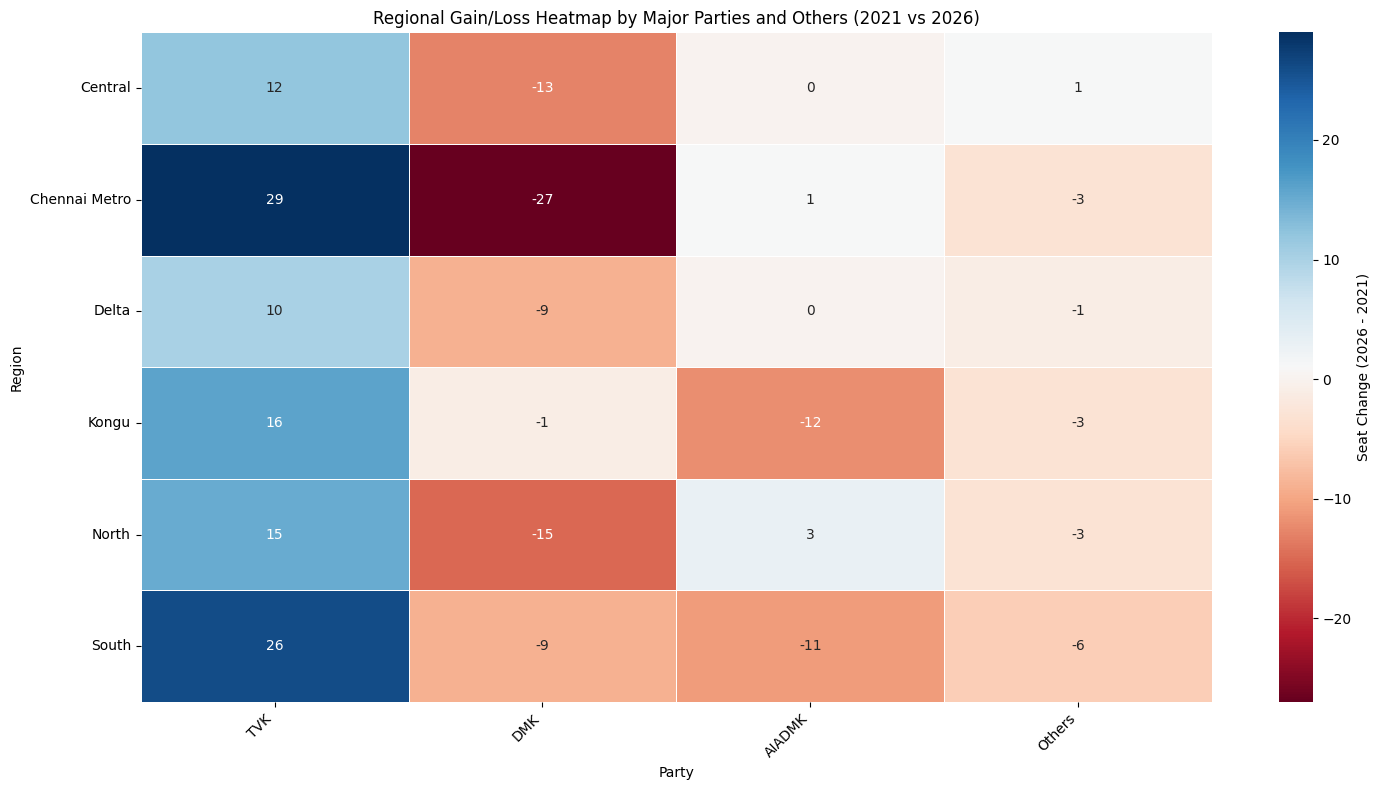

In [80]:
major_parties = ['TVK', 'DMK', 'AIADMK']

# Separate major parties and others
major_party_data = seat_change_pivot[major_parties]
other_party_data = seat_change_pivot.drop(columns=major_parties, errors='ignore')

# Sum seat changes for 'Others' category
seat_change_others = other_party_data.sum(axis=1).to_frame(name='Others')

# Combine major parties and 'Others'
seat_change_filtered = pd.concat([major_party_data, seat_change_others], axis=1)

plt.figure(figsize=(15, 8))
sns.heatmap(seat_change_filtered, annot=True, fmt=".0f", cmap='RdBu', linewidths=.5, cbar_kws={'label': 'Seat Change (2026 - 2021)'})
plt.title('Regional Gain/Loss Heatmap by Major Parties and Others (2021 vs 2026)')
plt.xlabel('Party')
plt.ylabel('Region')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **Chart 2: Regional Shifts (Bar chart)**

In [81]:
major_parties = ['TVK', 'DMK', 'AIADMK']

# Filter for major parties
df_major_parties = regional_party_seat_counts[regional_party_seat_counts['party'].isin(major_parties)].copy()

# Filter for other parties
df_other_parties = regional_party_seat_counts[~regional_party_seat_counts['party'].isin(major_parties)].copy()

# Sum seat changes for 'Others' category per region
df_others_agg = df_other_parties.groupby('region')['seat_change'].sum().reset_index()
df_others_agg['party'] = 'Others'
# For 'Others', seats_2021 and seats_2026 will also be summed up
df_others_agg['seats_2021'] = df_other_parties.groupby('region')['seats_2021'].sum().values
df_others_agg['seats_2026'] = df_other_parties.groupby('region')['seats_2026'].sum().values

# Concatenate major parties data with the 'Others' aggregated data
df_shifts_filtered = pd.concat([df_major_parties, df_others_agg], ignore_index=True)

# Create the 'region_party' column and sort for plotting
df_shifts_filtered['region_party'] = df_shifts_filtered['region'] + ' - ' + df_shifts_filtered['party']
df_shifts_filtered_sorted = df_shifts_filtered.sort_values(by='seat_change', ascending=False)

display(df_shifts_filtered_sorted.head())

,region,party,seats_2021,seats_2026,seat_change,abs_seat_change,region_party
5,Chennai Metro,TVK,0.0,29.0,29.0,29.0,Chennai Metro - TVK
17,South,TVK,0.0,26.0,26.0,26.0,South - TVK
11,Kongu,TVK,0.0,16.0,16.0,16.0,Kongu - TVK
14,North,TVK,0.0,15.0,15.0,15.0,North - TVK
2,Central,TVK,0.0,12.0,12.0,12.0,Central - TVK


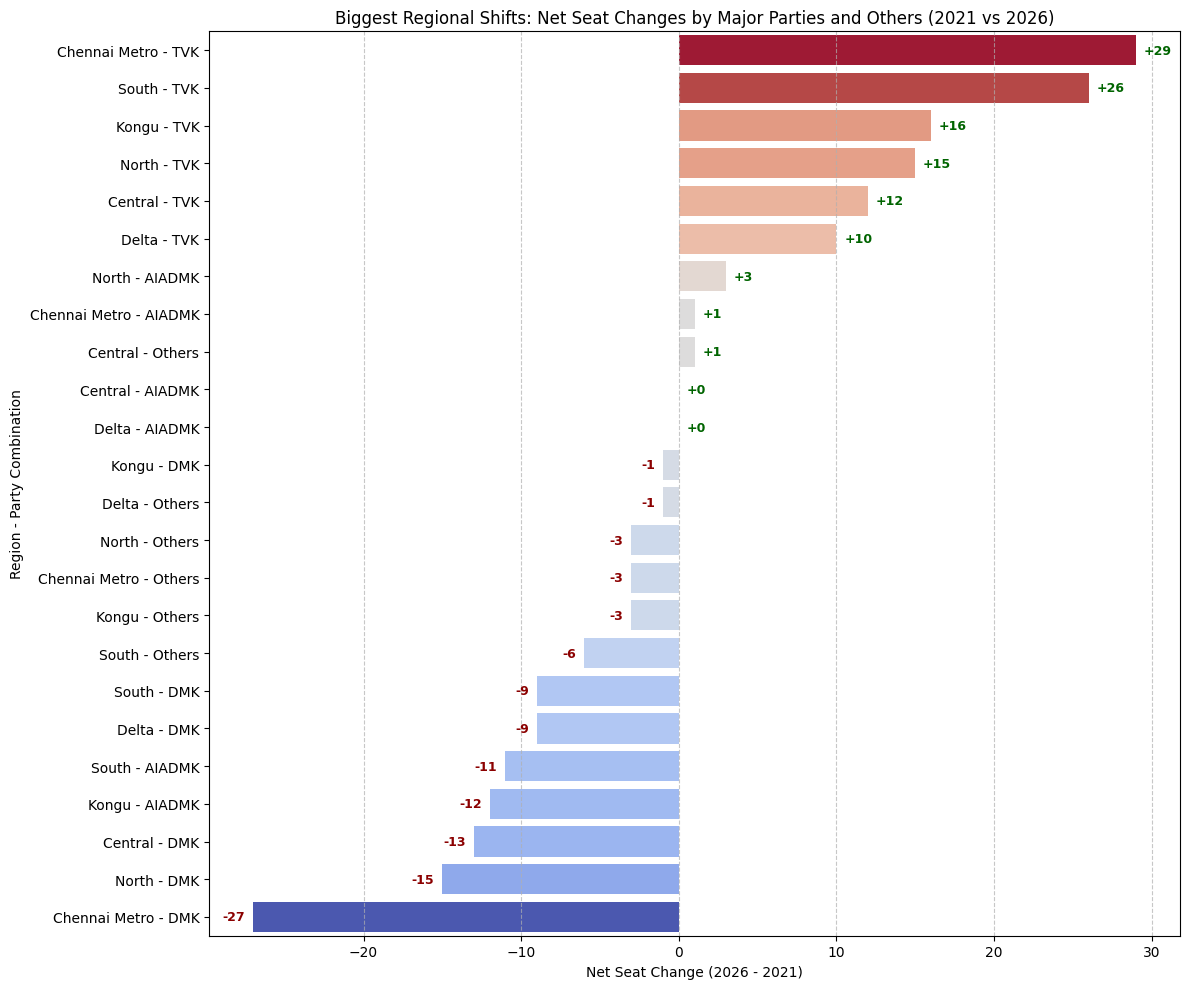

In [82]:
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='seat_change', y='region_party', data=df_shifts_filtered_sorted, palette='coolwarm', hue='seat_change', dodge=False, legend=False)
plt.title('Biggest Regional Shifts: Net Seat Changes by Major Parties and Others (2021 vs 2026)')
plt.xlabel('Net Seat Change (2026 - 2021)')
plt.ylabel('Region - Party Combination')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add seat_change values as text annotations on the bars
for i, row in enumerate(df_shifts_filtered_sorted.iterrows()):
    seat_change_val = int(row[1]['seat_change']) # Get the seat_change value

    # Determine text position and alignment based on the sign of seat_change
    if seat_change_val >= 0:
        x_text_pos = seat_change_val + 0.5  # Offset to the right of the bar's end
        ha_align = 'left'
        color = 'darkgreen'
    else:
        x_text_pos = seat_change_val - 0.5  # Offset to the left of the bar's end
        ha_align = 'right'
        color = 'darkred'

    ax.text(
        x_text_pos,
        i, # 'i' is the y-position for the bar in its plotted order
        f'{seat_change_val:+d}', # Format as +X or -X
        ha=ha_align,
        va='center',
        fontsize=9,
        color=color,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()